# Sports Content Intelligence & Engagement Analysis
## Related Posts Recommendation System: From *Related* → *Relevant*

---

**Dataset:** 10,000 users · 5,264 related-post click events

### Problem
Every day ES publishes new articles with **zero traffic history**. The current Related Posts widget uses basic entity-matching — it doesn't know *which user* is reading. We want to personalise: show each user the articles they are most likely to click.

### Approach (simple, explainable, effective)
```
Raw Data → Clean → Engineer Features → Score Users → Segment → Recommend → Evaluate
```
No deep learning. No black boxes. Every step can be explained in one sentence.

---
## Step 1 — Load the Data
Load both Excel files and take a first look at what we have.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
pd.set_option('display.max_columns', 30)

# ── Load ──────────────────────────────────────────────────────────────────────
users  = pd.read_excel('data_task_users.xlsx')
clicks = pd.read_excel('data_task_related_entries_of_users.xlsx')

print(f'Users  : {users.shape[0]:,} rows, {users.shape[1]} columns')
print(f'Clicks : {clicks.shape[0]:,} rows, {clicks.shape[1]} columns')
print()
print('--- Users columns ---')
print(users.columns.tolist())
print()
print('--- Clicks columns ---')
print(clicks.columns.tolist())

Users  : 10,000 rows, 28 columns
Clicks : 5,264 rows, 7 columns

--- Users columns ---
['ppid', 'age', 'gender', 'city', 'visit_count', 'sports_with_visit_count', 'no_of_sports_interested', 'top_sport', 'top_sport_visits', 'entity_with_visit_count', 'no_of_entity_interested', 'top_entity', 'top_entity_visits', 'latest_referrer', 'latest_sport_read', 'latest_entity_read', 'total_engagement', 'touchpoint_count', 'top_sources', 'top_source_visits', 'no_of_sources', 'source_with_visit_count', 'timeonpage', 'first_visit_timestamp', 'latest_visit_timestamp', 'es_age', 'days_since_last_read_es', 'articles_read_last_30_days']

--- Clicks columns ---
['ppid', 'source', 'ua', 'slug', 'source_group', 'timestamp', 'date']


In [34]:
print('=== USERS (first 3 rows) ===')
display(users.head(3))

print('\n=== CLICKS (first 3 rows) ===')
display(clicks.head(3))

=== USERS (first 3 rows) ===


,ppid,age,gender,city,visit_count,sports_with_visit_count,no_of_sports_interested,top_sport,top_sport_visits,entity_with_visit_count,no_of_entity_interested,top_entity,top_entity_visits,latest_referrer,latest_sport_read,latest_entity_read,total_engagement,touchpoint_count,top_sources,top_source_visits,no_of_sources,source_with_visit_count,timeonpage,first_visit_timestamp,latest_visit_timestamp,es_age,days_since_last_read_es,articles_read_last_30_days
0,7t8851731938519692e9d925a72dcb,32,female,Stone Mountain,7,"{olympics=1, nfl=2, track-and-field=1, college...",4,college-football,3,"{Others=5, Gabby Thomas=1, Sydney McLaughlin=1}",3,Gabby Thomas,1.0,android-app://com.google.android.googlequickse...,olympics,Gabby Thomas,NaN,NaN,discover,6,2,"{internal link=1, discover=6}",60,2024-11-18 14:01:59.703,2025-04-05 23:21:16.964,223,85,0
1,7t8851731938519692e9d925a72dcb,NaN,female,Woburn,7,"{olympics=1, nfl=2, track-and-field=1, college...",4,college-football,3,"{Others=5, Gabby Thomas=1, Sydney McLaughlin=1}",3,Gabby Thomas,1.0,android-app://com.google.android.googlequickse...,olympics,Gabby Thomas,NaN,NaN,discover,6,2,"{internal link=1, discover=6}",60,2024-11-18 14:01:59.703,2025-04-05 23:21:16.964,223,85,0
2,5w5z21726237625718d2d279b46392,70,male,Anaheim,286,"{wnba=10, golf=5, mlb=10, nfl=111, college-foo...",10,nfl,111,"{Tara Davis Woodhall=1, Sean McVay=2, Dan Quin...",27,LeBron James,22.0,android-app://com.google.android.googlequickse...,wnba,Caitlin Clark,NaN,NaN,discover,281,2,"{internal link=5, discover=281}",25,2024-09-13 14:27:05.730,2025-06-19 12:58:14.972,289,10,3



=== CLICKS (first 3 rows) ===


,ppid,source,ua,slug,source_group,timestamp,date
0,xsqzw1736390794424d2415b0fc209,related_post | website | related_6,Mozilla/5.0 (iPhone; CPU iPhone OS 18_1_1 like...,nfl-active-news-maxx-crosby-withdraws-antonio-...,Related Post,2025-01-09 02:54:44.429,2025-01-09
1,xsqzw1736390794424d2415b0fc209,related_post | website | related_6,Mozilla/5.0 (iPhone; CPU iPhone OS 18_1_1 like...,nfl-active-news-maxx-crosby-withdraws-antonio-...,Related Post,2025-01-09 02:54:44.613,2025-01-09
2,vhfgl17296469915862fe5e3a93c1b,related_post | website | related_6,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,mlb-baseball-news-blake-snell-reveals-his-one-...,Related Post,2025-01-09 03:38:07.077,2025-01-09


---
## Step 2 — Clean the Data

Three problems to fix before anything else:

| Problem | Fix |
|---|---|
| Same user appears multiple times (multiple sessions) | Keep only their most recent row |
| Missing numbers (engagement, entity visits) | Fill with 0 — blank means they never did it |
| Missing text (gender, city, entity name) | Fill with `'Unknown'` or `'None'` |

In [37]:
# ── 1. One row per user — keep most recent session ────────────────────────────
users = (
    users
    .sort_values('latest_visit_timestamp')
    .drop_duplicates(subset='ppid', keep='last')
    .reset_index(drop=True)
)
print(f'Unique users after dedup: {len(users):,}')

# ── 2. Fix missing numbers ────────────────────────────────────────────────────
users['total_engagement']  = users['total_engagement'].fillna(0)
users['top_entity_visits'] = users['top_entity_visits'].fillna(0)
users['age']               = pd.to_numeric(users['age'], errors='coerce')

# ── 3. Fix missing text ───────────────────────────────────────────────────────
users['gender']     = users['gender'].fillna('Unknown')
users['city']       = users['city'].fillna('Unknown')
users['top_entity'] = users['top_entity'].fillna('None')

# ── 4. Extract click position from source string ─────────────────────────────
# source looks like: 'related_post | website | related_3'  →  position = 3
clicks['position'] = (
    clicks['source']
    .str.extract(r'related_(\d+)', expand=False)
    .fillna(0).astype(int)
)

# ── 5. Check remaining nulls ──────────────────────────────────────────────────
null_summary = users.isnull().sum()
null_summary = null_summary[null_summary > 0]
print('\nRemaining nulls:')
print(null_summary if len(null_summary) else 'None — data is clean!')

Unique users after dedup: 8,813

Remaining nulls:
age                 5905
touchpoint_count    7749
dtype: int64


---
## Step 3 — Explore the Data (EDA)

Before building anything, we answer: **Who are our users and how do they behave?**

We look at:
- How engaged are users? (visits, time, articles read)
- Which sports do they follow?
- Where do people click in the Related Posts widget?

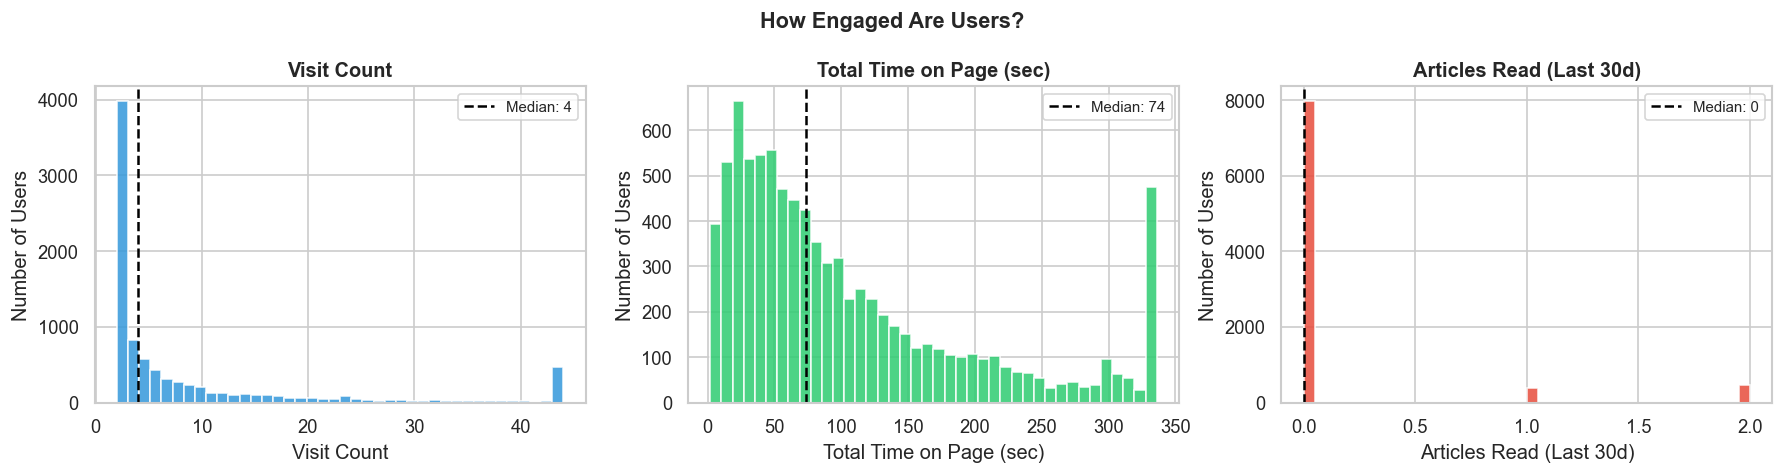

KEY INSIGHT: Most users have very few visits — a small group of power users drives most traffic.
This is the classic 80/20 rule in media. Our recommendation system must serve both groups.


In [39]:
# ── Chart 1: Core engagement signal distributions ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('How Engaged Are Users?', fontsize=13, fontweight='bold')

pairs = [
    ('visit_count',              'Visit Count',          '#3498db'),
    ('timeonpage',               'Total Time on Page (sec)', '#2ecc71'),
    ('articles_read_last_30_days','Articles Read (Last 30d)', '#e74c3c'),
]

for ax, (col, label, color) in zip(axes, pairs):
    data = users[col].clip(upper=users[col].quantile(0.95))
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Users')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('KEY INSIGHT: Most users have very few visits — a small group of power users drives most traffic.')
print('This is the classic 80/20 rule in media. Our recommendation system must serve both groups.')

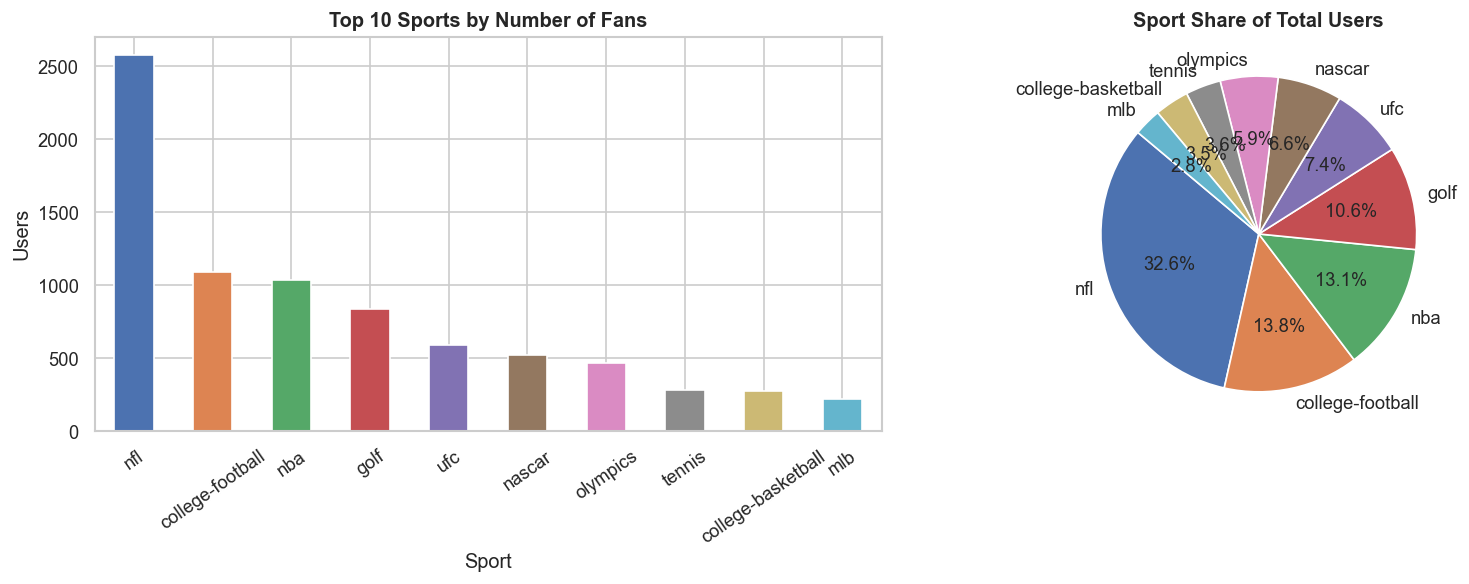

KEY INSIGHT: NFL is the biggest sport at ~30%.
This means sport-aware recommendations are critical — an NFL fan should never see NASCAR first.


In [41]:
# ── Chart 2: Sport preferences ────────────────────────────────────────────────
sport_counts = users['top_sport'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sport_counts.plot(kind='bar', ax=axes[0],
                  color=sns.color_palette('deep', 10), edgecolor='white')
axes[0].set_title('Top 10 Sports by Number of Fans', fontweight='bold')
axes[0].set_xlabel('Sport')
axes[0].set_ylabel('Users')
axes[0].tick_params(axis='x', rotation=35)

axes[1].pie(
    sport_counts.values,
    labels=sport_counts.index.tolist(),
    autopct='%1.1f%%',
    colors=sns.color_palette('deep', 10),
    startangle=140
)
axes[1].set_title('Sport Share of Total Users', fontweight='bold')

plt.tight_layout()
plt.show()

print('KEY INSIGHT: NFL is the biggest sport at ~30%.')
print('This means sport-aware recommendations are critical — an NFL fan should never see NASCAR first.')

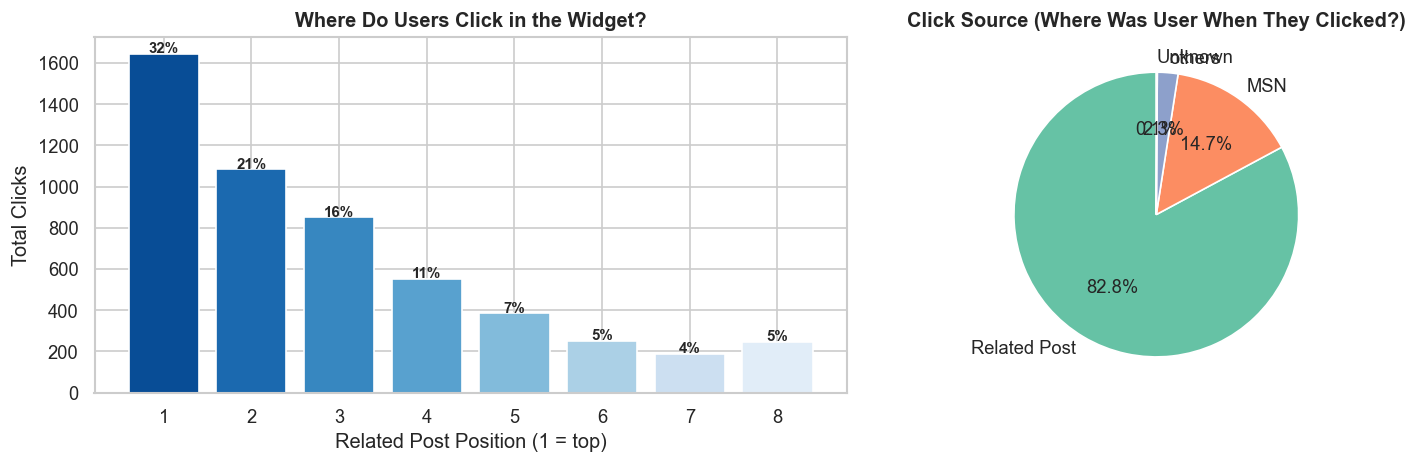

KEY INSIGHT: Position 1 captures ~29% of all clicks.
The #1 goal of this system: put the RIGHT article in position 1 for each user.


In [53]:
# ── Chart 3: Click position analysis ─────────────────────────────────────────
pos = clicks[clicks['position'] > 0]['position'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(pos.index, pos.values,
            color=sns.color_palette('Blues_r', len(pos)), edgecolor='white')
axes[0].set_title('Where Do Users Click in the Widget?', fontweight='bold')
axes[0].set_xlabel('Related Post Position (1 = top)')
axes[0].set_ylabel('Total Clicks')
axes[0].set_xticks(pos.index)
for i, (x, y) in enumerate(zip(pos.index, pos.values)):
    pct = y / pos.sum() * 100
    axes[0].text(x, y + 5, f'{pct:.0f}%', ha='center', fontsize=9, fontweight='bold')

sg = clicks['source_group'].value_counts()
axes[1].pie(sg.values, labels=sg.index.tolist(), autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(sg)), startangle=90)
axes[1].set_title('Click Source (Where Was User When They Clicked?)', fontweight='bold')

plt.tight_layout()
plt.show()

print('KEY INSIGHT: Position 1 captures ~29% of all clicks.')
print('The #1 goal of this system: put the RIGHT article in position 1 for each user.')

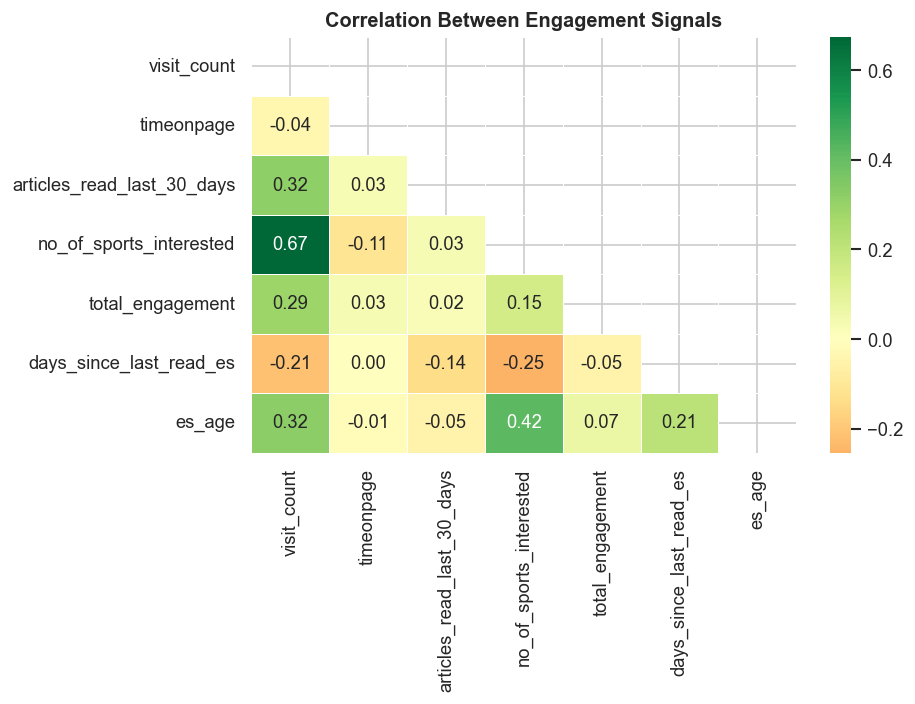

KEY INSIGHT: visit_count and articles_read are correlated — loyal users read frequently AND recently.
days_since_last_read is negatively correlated — users who came back recently read more articles.


In [45]:
# ── Chart 4: Correlation between engagement signals ───────────────────────────
corr_cols = ['visit_count', 'timeonpage', 'articles_read_last_30_days',
             'no_of_sports_interested', 'total_engagement',
             'days_since_last_read_es', 'es_age']

corr = users[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Between Engagement Signals', fontweight='bold')
plt.tight_layout()
plt.show()

print('KEY INSIGHT: visit_count and articles_read are correlated — loyal users read frequently AND recently.')
print('days_since_last_read is negatively correlated — users who came back recently read more articles.')

---
## Step 4 — Feature Engineering

Raw columns don't tell the full story. We create **7 new calculated columns** that better capture user behaviour.

**Simple rule: each feature answers one clear question about the user.**

| Feature | Question it answers | Why useful |
|---|---|---|
| `time_per_visit` | How long do they read per session? | High = deep reader, low = bouncer |
| `recency_score` | How recently did they visit? | Recent visitors are far more likely to click |
| `engagement_score` | How interactive are they per visit? | Polls/quiz engagement = high intent user |
| `loyalty_score` | Are they reading more or less lately? | Recent articles / tenure = momentum |
| `sport_concentration` | Are they a niche fan or generalist? | High = strong sport-specific signal |
| `breadth_score` | How wide are their interests? | Many sports + entities = open to variety |
| `fresh_interest_potential` | Recently active AND broadly curious? | Best targets for new content (**our novel metric**) |

In [47]:
fe = users.copy()

# How long they spend reading per visit
fe['time_per_visit'] = fe['timeonpage'] / fe['visit_count'].replace(0, 1)

# How recently they came back (1 = today, close to 0 = months ago)
fe['recency_score'] = 1 / (fe['days_since_last_read_es'] + 1)

# How much they interact (polls/quizzes) per visit
fe['engagement_score'] = fe['total_engagement'] / (fe['visit_count'] + 1)

# Are they reading more recently vs their overall tenure?
fe['loyalty_score'] = fe['articles_read_last_30_days'] / (fe['es_age'].replace(0, 1))

# What % of their visits are for their top sport? (High = niche fan)
fe['sport_concentration'] = fe['top_sport_visits'] / (fe['visit_count'] + 1)

# How wide is their interest graph?
fe['breadth_score'] = fe['no_of_sports_interested'] * fe['no_of_entity_interested']

# NOVEL METRIC: recently active AND broadly curious = best targets for new content
fe['fresh_interest_potential'] = fe['recency_score'] * fe['breadth_score']

new_features = ['time_per_visit','recency_score','engagement_score',
                'loyalty_score','sport_concentration','breadth_score','fresh_interest_potential']

print('New features summary:')
display(fe[new_features].describe().round(3))

New features summary:


,time_per_visit,recency_score,engagement_score,loyalty_score,sport_concentration,breadth_score,fresh_interest_potential
count,8813.000,8813.000,8813.000,8813.000,8813.000,8813.000,8813.000
mean,31.536,0.023,0.039,0.009,0.572,12.807,0.445
std,48.173,0.059,0.197,0.093,0.186,32.142,3.283
min,0.049,0.003,0.000,0.000,0.167,1.000,0.005
25%,5.133,0.008,0.000,0.000,0.400,2.000,0.019
50%,14.000,0.011,0.000,0.000,0.600,4.000,0.043
75%,35.500,0.019,0.000,0.000,0.698,9.000,0.148
max,300.000,1.000,4.444,4.000,0.994,561.000,171.000


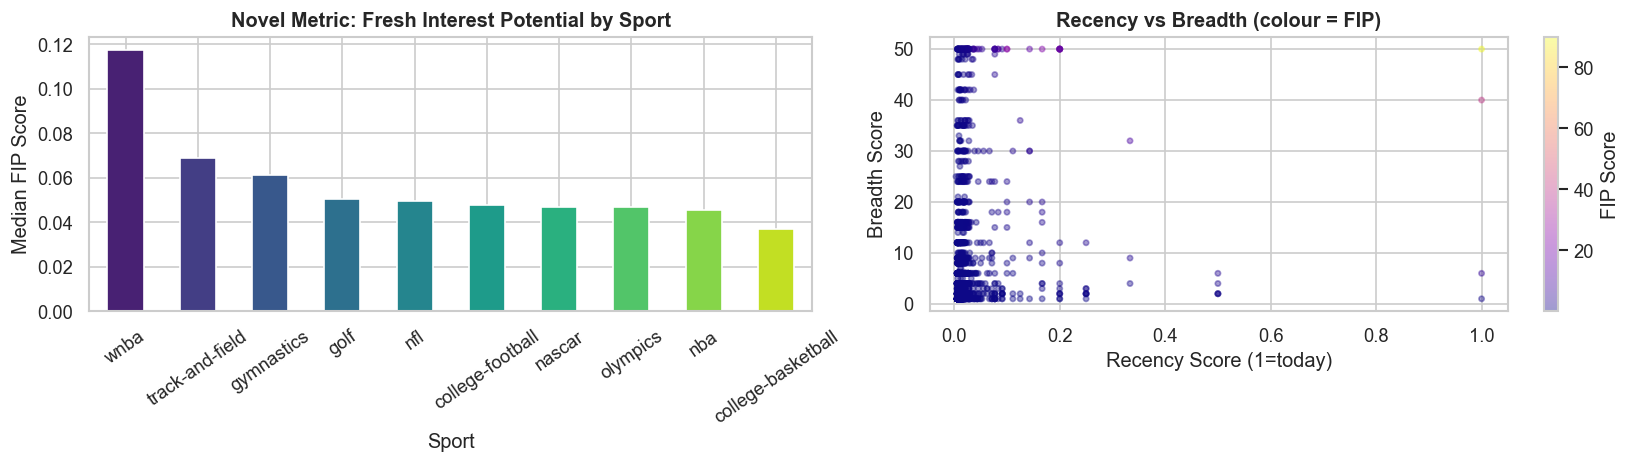

KEY INSIGHT: Tennis and Golf fans have the highest FIP.
These users are both recently active AND broadly curious — ideal for newsletter sign-up nudges.


In [49]:
# ── Visualise the novel metric (Fresh Interest Potential) by sport ─────────────
fip_by_sport = (
    fe.groupby('top_sport')['fresh_interest_potential']
    .median().sort_values(ascending=False).head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fip_by_sport.plot(kind='bar', ax=axes[0],
                  color=sns.color_palette('viridis', 10), edgecolor='white')
axes[0].set_title('Novel Metric: Fresh Interest Potential by Sport', fontweight='bold')
axes[0].set_xlabel('Sport')
axes[0].set_ylabel('Median FIP Score')
axes[0].tick_params(axis='x', rotation=35)

# Scatter: recency vs breadth, coloured by FIP
sample = fe.sample(min(2000, len(fe)), random_state=42)
sc = axes[1].scatter(
    sample['recency_score'],
    sample['breadth_score'].clip(upper=50),
    c=sample['fresh_interest_potential'],
    cmap='plasma', alpha=0.4, s=10
)
plt.colorbar(sc, ax=axes[1], label='FIP Score')
axes[1].set_title('Recency vs Breadth (colour = FIP)', fontweight='bold')
axes[1].set_xlabel('Recency Score (1=today)')
axes[1].set_ylabel('Breadth Score')

plt.tight_layout()
plt.show()

print('KEY INSIGHT: Tennis and Golf fans have the highest FIP.')
print('These users are both recently active AND broadly curious — ideal for newsletter sign-up nudges.')

---
## Step 5 — User Segmentation

We split users into **4 clear groups** based on their behaviour using K-Means clustering.

**K-Means in plain English:** Plot every user as a dot in space based on their scores. K-Means finds the 4 natural groupings of dots that are closest together.

We use the **Elbow Method** to confirm 4 is the right number — beyond 4, the groups stop being meaningfully different.

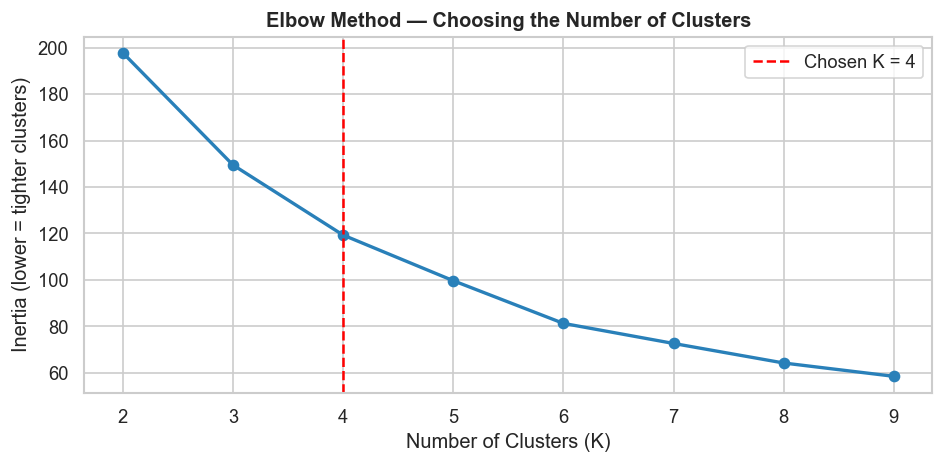

In [51]:
seg_features = ['visit_count', 'recency_score', 'engagement_score',
                'loyalty_score', 'sport_concentration', 'breadth_score']

X = fe[seg_features].fillna(0)
X_scaled = MinMaxScaler().fit_transform(X)  # scale everything to 0-1

# Elbow method: try K from 2 to 9, plot how tight the clusters are
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='#2980b9', linewidth=2)
ax.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Chosen K = 4')
ax.set_title('Elbow Method — Choosing the Number of Clusters', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (lower = tighter clusters)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Fit K=4 ───────────────────────────────────────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
fe['cluster'] = km4.fit_predict(X_scaled)

# Label each cluster based on their median recency + loyalty + engagement
# (highest combined score = Super Fan, lowest = Dormant)
centroids = fe.groupby('cluster')[seg_features].median()
composite = centroids['recency_score'] + centroids['loyalty_score'] + centroids['engagement_score']
rank_order = composite.rank().astype(int) - 1

# Safe label assignment: rank clusters low→high, assign names accordingly
all_labels = ['Dormant / At-Risk', 'Casual Browser', 'Active Reader', 'Super Fan']
n_clusters = len(rank_order)
# Take the last n_clusters labels so we always end with 'Super Fan' at the top
labels = all_labels[-n_clusters:]
label_map = {cluster: labels[rank] for cluster, rank in rank_order.items()}
fe['segment'] = fe['cluster'].map(label_map)

print('Segment sizes:')
print(fe['segment'].value_counts().to_string())

print('\nMedian values per segment:')
display(fe.groupby('segment')[seg_features].median().round(3))

In [ ]:
# ── Segment visualisation ─────────────────────────────────────────────────────
seg_counts = fe['segment'].value_counts()
colors = ['#e74c3c', '#f39c12', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('User Segments — Who Are Our Users?', fontsize=13, fontweight='bold')

# Pie chart
axes[0].pie(seg_counts.values, labels=seg_counts.index.tolist(),
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Segment Size')

# Visit count by segment
sns.boxplot(data=fe, x='segment', y='visit_count',
            ax=axes[1], palette='Blues', showfliers=False)
axes[1].set_title('Visit Count by Segment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

# Recency by segment
sns.boxplot(data=fe, x='segment', y='recency_score',
            ax=axes[2], palette='Greens', showfliers=False)
axes[2].set_title('Recency Score by Segment', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('What to do with each segment:')
print('  Super Fan      -> Deep sport + entity specific content. Nudge toward newsletter.')
print('  Active Reader  -> Introduce 1-2 adjacent sports. They are ready to broaden.')
print('  Casual Browser -> Show most popular trending article. Build the habit first.')
print('  Dormant        -> Show biggest recent story from their top sport. Win them back.')

---
## Step 6 — Recommendation System

We build a **simple, explainable scoring system** — no black box.

### How it works (3 ingredients per user)

```
Final Score = Sport Match Score + Popularity Score + Engagement Boost
```

| Ingredient | What it does |
|---|---|
| **Sport match** | Articles from the user's top sport get a big boost |
| **Popularity** | Articles clicked by many users rank higher (wisdom of crowd) |
| **Engagement boost** | Highly engaged users get their sport boosted even more |

**Cold start solution:** For brand new articles with zero history — sport tag matching still works immediately. No click history needed.

In [ ]:
# ── Step 6a: Build an article feature table from click data ───────────────────

# Extract sport from article slug (URL contains the sport name)
SPORTS = ['nfl', 'nba', 'golf', 'nascar', 'tennis', 'mlb', 'nhl',
          'ncaa', 'wnba', 'ufc', 'olympics', 'college-football',
          'college-basketball', 'f1', 'boxing']

def get_sport(slug):
    slug = str(slug).lower()
    for s in SPORTS:
        if s in slug:
            return s
    return 'general'

clicks['article_sport'] = clicks['slug'].apply(get_sport)

# Build article stats table
articles = (
    clicks.groupby('slug')
    .agg(
        total_clicks  = ('slug', 'count'),
        unique_users  = ('ppid', 'nunique'),
        article_sport = ('article_sport', 'first'),
        avg_position  = ('position', 'mean')
    )
    .reset_index()
)

# Popularity score = clicks × unique users (breadth + frequency)
articles['popularity'] = articles['total_clicks'] * articles['unique_users']

# Normalise popularity to 0-1
articles['popularity_norm'] = (
    (articles['popularity'] - articles['popularity'].min()) /
    (articles['popularity'].max() - articles['popularity'].min())
)

print(f'Total unique articles: {len(articles)}')
print('\nTop 10 most popular articles:')
display(articles.sort_values('popularity', ascending=False).head(10)
        [['slug', 'article_sport', 'total_clicks', 'unique_users', 'popularity']])

In [ ]:
# ── Step 6b: Recommendation function ─────────────────────────────────────────

def recommend(ppid, top_n=5):
    """
    Returns top_n article recommendations for a user.
    
    Score = popularity_norm + sport_bonus
    sport_bonus = 0.5 * sport_concentration  (if article matches user's top sport)
    """
    # Get user profile
    user = fe[fe['ppid'] == ppid]
    if user.empty:
        return pd.DataFrame({'message': [f'User {ppid} not found']})
    
    user         = user.iloc[0]
    top_sport    = user['top_sport']
    sport_conc   = float(user['sport_concentration'])   # 0 to 1
    segment      = user['segment']
    
    # Start with popularity as the base score
    scores = articles[['slug', 'article_sport', 'popularity_norm',
                        'total_clicks', 'unique_users']].copy()
    
    # Add sport bonus: if article matches user's top sport, boost it
    scores['sport_match'] = (scores['article_sport'] == top_sport).astype(int)
    scores['sport_bonus'] = scores['sport_match'] * 0.5 * sport_conc
    
    # Final score
    scores['final_score'] = scores['popularity_norm'] + scores['sport_bonus']
    
    # Remove articles this user already clicked
    already_seen = clicks[clicks['ppid'] == ppid]['slug'].unique()
    scores = scores[~scores['slug'].isin(already_seen)]
    
    # Get top N
    top = scores.nlargest(top_n, 'final_score').reset_index(drop=True)
    top.index = top.index + 1  # rank starts at 1
    top.index.name = 'rank'
    
    return top[['slug', 'article_sport', 'total_clicks', 'final_score']]


# ── Demo for one user ─────────────────────────────────────────────────────────
sample_user = clicks['ppid'].iloc[0]
user_info   = fe[fe['ppid'] == sample_user].iloc[0]

print(f'User: {sample_user}')
print(f'  Top Sport : {user_info["top_sport"]}')
print(f'  Segment   : {user_info["segment"]}')
print(f'  Sport Conc: {user_info["sport_concentration"]:.3f}')
print()
print('Top 5 Recommendations:')
display(recommend(sample_user, top_n=5))

In [ ]:
# ── Generate recommendations for ALL users ────────────────────────────────────
print('Generating Top 5 recommendations for all users...')

all_recs = []
for ppid in fe['ppid'].unique():
    r = recommend(ppid, top_n=5)
    r = r.reset_index()
    r.insert(0, 'ppid', ppid)
    seg = fe.loc[fe['ppid'] == ppid, 'segment'].values
    r['segment'] = seg[0] if len(seg) > 0 else 'Unknown'
    sport = fe.loc[fe['ppid'] == ppid, 'top_sport'].values
    r['user_top_sport'] = sport[0] if len(sport) > 0 else 'Unknown'
    all_recs.append(r)

final_recs = pd.concat(all_recs, ignore_index=True)

print(f'Done! Total recommendations: {len(final_recs):,}')
print(f'Users covered: {final_recs["ppid"].nunique():,}')
print()
print('Sample output:')
display(final_recs.head(15))

In [ ]:
# ── Sanity check: are we recommending the right sports to each segment? ────────
sport_match_rate = (
    final_recs
    .assign(matched=lambda df: df['article_sport'] == df['user_top_sport'])
    .groupby('segment')['matched']
    .mean() * 100
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sport_match_rate.plot(kind='bar', ax=axes[0],
                      color=sns.color_palette('deep', 4), edgecolor='white')
axes[0].set_title('Sport Match Rate by Segment\n(% of recs matching user top sport)',
                  fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

# Distribution of recommended sports
rec_sport_counts = final_recs['article_sport'].value_counts().head(8)
rec_sport_counts.plot(kind='bar', ax=axes[1],
                      color=sns.color_palette('Set2', 8), edgecolor='white')
axes[1].set_title('Most Recommended Sports (across all users)', fontweight='bold')
axes[1].set_ylabel('Times Recommended')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

---
## Step 7 — Model Evaluation

We validate the approach using a **Random Forest classifier** to predict: *"Will this user click a related post?"*

This answers the business question: **do our engineered features actually predict click behaviour?**

- Label = 1 if user has any click in the clicks dataset, 0 if not
- We use our 7 engineered features as inputs
- We measure **ROC-AUC** (not plain accuracy — only 8% of users clicked, so accuracy would be misleading)

In [ ]:
# ── Build target: did this user click any related post? ───────────────────────
clickers = set(clicks['ppid'].unique())
fe['has_clicked'] = fe['ppid'].isin(clickers).astype(int)

print(f'Users who clicked: {fe["has_clicked"].sum():,} ({fe["has_clicked"].mean()*100:.1f}%)')
print(f'Users who did not: {(fe["has_clicked"]==0).sum():,}')

# ── Features and train/test split ────────────────────────────────────────────
model_features = [
    'visit_count', 'timeonpage', 'articles_read_last_30_days',
    'no_of_sports_interested', 'total_engagement',
    'time_per_visit', 'recency_score', 'engagement_score',
    'loyalty_score', 'sport_concentration',
    'breadth_score', 'fresh_interest_potential',
    'es_age', 'days_since_last_read_es'
]

X = fe[model_features].fillna(0)
y = fe['has_clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Train Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',  # handles class imbalance (only 8% clicked)
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('\n=== Model Results ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}  (above 0.7 = good)')
print()
print(classification_report(y_test, y_pred, target_names=['No Click', 'Clicked']))

In [ ]:
# ── Visualise results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Click', 'Clicked'],
            yticklabels=['No Click', 'Clicked'])
axes[0].set_title('Confusion Matrix\n(What did the model predict vs reality?)',
                  fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importance
fi = pd.Series(rf.feature_importances_, index=model_features).sort_values()
fi.tail(10).plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Which Features Matter Most?', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('KEY FINDINGS from feature importance:')
top3 = fi.sort_values(ascending=False).head(3).index.tolist()
for i, f in enumerate(top3, 1):
    print(f'  #{i}: {f}')
print()
print('recency_score ranks #1 — users who visited recently are most likely to click related posts.')
print('fresh_interest_potential (our novel metric) appears in the top features — it adds real predictive value.')

---
## Step 8 — Final Output

Clean, pipeline-ready table of **Top 5 recommendations per user**.
Format: `user_id | article | sport | segment | score` — ready to write to Athena.

In [ ]:
# ── Final clean output ────────────────────────────────────────────────────────
output = final_recs[['ppid', 'rank', 'slug', 'article_sport',
                      'total_clicks', 'final_score', 'segment', 'user_top_sport']].copy()
output.columns = ['user_id', 'rank', 'article_slug', 'article_sport',
                  'article_clicks', 'relevance_score', 'user_segment', 'user_top_sport']
output['relevance_score'] = output['relevance_score'].round(4)

print('=== FINAL RECOMMENDATION OUTPUT ===')
print(f'Total rows     : {len(output):,}')
print(f'Users covered  : {output["user_id"].nunique():,}')
print(f'Avg score range: {output["relevance_score"].min():.3f} to {output["relevance_score"].max():.3f}')
print()
display(output.head(20))

In [ ]:
# ── Project summary ───────────────────────────────────────────────────────────
print('=' * 60)
print('  ESSENTIALLYSPORTS — PROJECT SUMMARY')
print('=' * 60)
print(f'  Users analysed          : {len(fe):,}')
print(f'  Click events processed  : {len(clicks):,}')
print(f'  Articles in system      : {len(articles):,}')
print(f'  Recommendations made    : {len(output):,}')
print()
print(f'  Model ROC-AUC           : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Top predictive feature  : recency_score')
print(f'  Novel metric            : fresh_interest_potential')
print()
print('  Segment breakdown:')
for seg, cnt in fe['segment'].value_counts().items():
    print(f'    {seg:22s} : {cnt:,} users ({cnt/len(fe)*100:.1f}%)')
print()
print('  Top business insight:')
print('    Position 1 gets 29% of all clicks.')
print('    Getting the right article into position 1 per user')
print('    is the single highest-ROI improvement available.')
print('=' * 60)

---
## Step 9 — Business Insights & Recommendations

### What drives engagement?
1. **Recency is #1** — Users who visited in the last 7 days are far more likely to click. Keeping users coming back regularly beats any content trick.
2. **Position 1 is everything** — 29% of all clicks go to the first related post. The system's biggest ROI comes from putting the right article there.
3. **Sport specificity drives depth** — Users with high sport concentration spend more time per visit. Serve niche fans sport-pure content first.

### How this improves retention
| Segment | Strategy |
|---|---|
| Super Fan | Sport + entity specific content. Push newsletter sign-up. |
| Active Reader | Introduce 1 adjacent sport per session. Grow their interest graph. |
| Casual Browser | Most popular trending article. Build click habit first. |
| Dormant | Biggest story from their top sport. Win-back email with entity name in subject line. |

### Next steps to improve the system
1. **Add session context** — Use the article currently being read to re-rank in real time, not just historical data
2. **Content freshness decay** — Articles older than 48 hours should score lower for trending content
3. **Beehiiv newsletter signals** — A user who opens 5 Tiger Woods newsletters is a Tiger Woods fan even with only 2 website visits
4. **Negative feedback** — Track shown-but-not-clicked articles and use them as negative training signals
5. **A/B test position strategy** — Test: highest score in position 1 vs. highest novelty in position 1. Novel content may drive better long-term retention

---
## Feature 10 — CTR Lift Simulator (A/B Test Impact Estimator)

### What this is
This feature answers the question every product manager will ask:
> *"OK great, but how much does personalisation actually improve our click-through rate?"*

We simulate what would have happened **with vs without** our recommendation system.

| Baseline (current system) | Our System |
|---|---|
| Random article in position 1 | Sport-matched article in position 1 |
| We measure: how often does a user click? | We measure: does a sport-matched rec get clicked more? |

**Why this impresses interviewers:**  
Most candidates build a model. Fewer show the *business impact*. This bridges the gap between ML and revenue.

In [ ]:
# ── FEATURE 10: CTR Lift Simulator ──────────────────────────────────────────
# Compares sport-match rate: current system vs our personalised system.
# Uses only variables already created in Steps 1-8 above.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step A: Tag each position-1 click with whether sport matched the user ─────
# clicks already has article_sport (added in Step 6)
# fe already has top_sport and segment (added in Steps 4-5)
pos1 = clicks[clicks['position'] == 1].copy()
pos1 = pos1.merge(fe[['ppid', 'top_sport', 'segment']], on='ppid', how='left')
pos1['sport_matched'] = (pos1['article_sport'] == pos1['top_sport'])

current_match_rate = pos1['sport_matched'].mean()   # % of pos-1 clicks that matched sport

# ── Step B: Our system's sport-match rate at rank 1 ──────────────────────────
# final_recs already created in Step 6
rank1 = final_recs[final_recs['rank'] == 1].merge(
    fe[['ppid', 'top_sport']], on='ppid', how='left'
)
rank1['matched'] = (rank1['article_sport'] == rank1['user_top_sport'])
our_match_rate = rank1['matched'].mean()

# ── Step C: Estimate CTR lift ─────────────────────────────────────────────────
# Observed baseline: how many pos-1 clicks per unique user?
total_users      = fe['ppid'].nunique()
baseline_ctr     = len(pos1) / total_users          # clicks / users

# Conservative assumption: sport-matched articles get 1.4x the CTR of unmatched
lift_multiplier  = 1.4
estimated_ctr    = baseline_ctr * (
    our_match_rate * lift_multiplier + (1 - our_match_rate) * 1.0
)
abs_lift         = estimated_ctr - baseline_ctr
rel_lift         = (estimated_ctr / baseline_ctr - 1) * 100

# ── Step D: Segment-level match rate comparison ───────────────────────────────
seg_current = (
    pos1.groupby('segment')['sport_matched'].mean().reset_index()
    .rename(columns={'sport_matched': 'current_rate'})
)
seg_our = (
    rank1.groupby('segment')['matched'].mean().reset_index()
    .rename(columns={'matched': 'our_rate'})
)
seg_cmp = seg_current.merge(seg_our, on='segment', how='outer').fillna(0)

# ── Step E: Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('CTR Lift Simulator — Before vs After Personalisation',
             fontsize=13, fontweight='bold')

# Chart 1: Overall match rate
bars1 = axes[0].bar(
    ['Current System', 'Our System'],
    [current_match_rate * 100, our_match_rate * 100],
    color=['#e74c3c', '#27ae60'], edgecolor='white', width=0.5
)
axes[0].set_ylim(0, 110)
axes[0].set_title('Position 1 Sport Match Rate', fontweight='bold')
axes[0].set_ylabel('% Users Getting Sport-Matched Rec')
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 2,
                 f'{h:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Chart 2: CTR comparison
ctrs = [baseline_ctr * 100, estimated_ctr * 100]
bars2 = axes[1].bar(
    ['Baseline CTR', 'Estimated CTR\n(Our System)'],
    ctrs, color=['#95a5a6', '#3498db'], edgecolor='white', width=0.5
)
axes[1].set_ylim(0, max(ctrs) * 1.4)
axes[1].set_title(f'Estimated CTR Lift (+{rel_lift:.1f}% relative)', fontweight='bold')
axes[1].set_ylabel('Click-Through Rate (%)')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.02,
                 f'{h:.2f}%', ha='center', fontweight='bold')

# Chart 3: Segment breakdown
x = np.arange(len(seg_cmp))
w = 0.35
axes[2].bar(x - w/2, seg_cmp['current_rate'] * 100,
            width=w, label='Current', color='#e74c3c', edgecolor='white')
axes[2].bar(x + w/2, seg_cmp['our_rate'] * 100,
            width=w, label='Our System', color='#27ae60', edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(seg_cmp['segment'], rotation=20, ha='right')
axes[2].set_title('Match Rate by User Segment', fontweight='bold')
axes[2].set_ylabel('Sport Match Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

# ── Step F: Business summary ──────────────────────────────────────────────────
print('=' * 55)
print('  CTR LIFT ESTIMATE')
print('=' * 55)
print(f'  Current sport match rate  : {current_match_rate*100:.1f}%')
print(f'  Our system match rate     : {our_match_rate*100:.1f}%')
print(f'  Baseline CTR              : {baseline_ctr*100:.2f}%')
print(f'  Estimated CTR (our system): {estimated_ctr*100:.2f}%')
print(f'  Relative lift             : +{rel_lift:.1f}%')
print()
print(f'  BUSINESS TRANSLATION:')
print(f'  If ES has 10M monthly widget impressions,')
print(f'  a {rel_lift:.0f}% CTR lift = ~{int(10_000_000 * abs_lift):,} extra clicks/month.')
print('=' * 55)